In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv(r"/content/train_and_test2.csv")
df.head()

,Passengerid,Age,Fare,Sex,sibsp,zero,zero.1,zero.2,zero.3,zero.4,...,zero.12,zero.13,zero.14,Pclass,zero.15,zero.16,Embarked,zero.17,zero.18,2urvived
0,1,22.0,7.2500,0,1,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0
1,2,38.0,71.2833,1,1,0,0,0,0,0,...,0,0,0,1,0,0,0.0,0,0,1
2,3,26.0,7.9250,1,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,1
3,4,35.0,53.1000,1,1,0,0,0,0,0,...,0,0,0,1,0,0,2.0,0,0,1
4,5,35.0,8.0500,0,0,0,0,0,0,0,...,0,0,0,3,0,0,2.0,0,0,0


In [3]:
df.shape

(1309, 28)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 28 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Passengerid  1309 non-null   int64  
 1   Age          1309 non-null   float64
 2   Fare         1309 non-null   float64
 3   Sex          1309 non-null   int64  
 4   sibsp        1309 non-null   int64  
 5   zero         1309 non-null   int64  
 6   zero.1       1309 non-null   int64  
 7   zero.2       1309 non-null   int64  
 8   zero.3       1309 non-null   int64  
 9   zero.4       1309 non-null   int64  
 10  zero.5       1309 non-null   int64  
 11  zero.6       1309 non-null   int64  
 12  Parch        1309 non-null   int64  
 13  zero.7       1309 non-null   int64  
 14  zero.8       1309 non-null   int64  
 15  zero.9       1309 non-null   int64  
 16  zero.10      1309 non-null   int64  
 17  zero.11      1309 non-null   int64  
 18  zero.12      1309 non-null   int64  
 19  zero.1

In [5]:
df.isnull().sum()

,0
Passengerid,0
Age,0
Fare,0
Sex,0
sibsp,0
zero,0
zero.1,0
zero.2,0
zero.3,0
zero.4,0


In [7]:
df = df.rename(columns={"2urvived": "Survived"})

In [8]:
df.columns

Index(['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1',
       'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7',
       'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13',
       'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17',
       'zero.18', 'Survived'],
      dtype='object')

In [9]:
df["Survived"].value_counts()

,count
Survived,
0,967
1,342


In [10]:
columns_to_drop = [col for col in df.columns if col.lower().startswith("zero")]

df = df.drop(columns=columns_to_drop)

df = df.drop("Passengerid", axis=1, errors="ignore")

In [11]:
df.head()

,Age,Fare,Sex,sibsp,Parch,Pclass,Embarked,Survived
0,22.0,7.2500,0,1,0,3,2.0,0
1,38.0,71.2833,1,1,0,1,0.0,1
2,26.0,7.9250,1,0,0,3,2.0,1
3,35.0,53.1000,1,1,0,1,2.0,1
4,35.0,8.0500,0,0,0,3,2.0,0


In [13]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
df.isnull().sum()

,0
Age,0
Fare,0
Sex,0
sibsp,0
Parch,0
Pclass,0
Embarked,0
Survived,0


In [14]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [22]:
categorical_cols = X.select_dtypes(include=["object"]).columns
print(categorical_cols)

Index([], dtype='object')


In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ],
    remainder="passthrough"
)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [25]:
X_train.shape, X_test.shape

((1047, 7), (262, 7))

In [26]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


In [27]:
logistic_model = LogisticRegression(max_iter=1000)

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [29]:
logistic_model.fit(X_train, y_train)

decision_tree_model.fit(X_train, y_train)

random_forest_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [30]:
logistic_pred = logistic_model.predict(X_test)

decision_tree_pred = decision_tree_model.predict(X_test)

random_forest_pred = random_forest_model.predict(X_test)

In [31]:
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]

decision_tree_prob = decision_tree_model.predict_proba(X_test)[:, 1]

random_forest_prob = random_forest_model.predict_proba(X_test)[:, 1]

In [32]:
def evaluate_model(name, y_test, predictions, probabilities):
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)
    roc_auc = roc_auc_score(y_test, probabilities)

    print(name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-Score:", f1)
    print("ROC-AUC:", roc_auc)
    print()

In [33]:
evaluate_model(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_prob
)

evaluate_model(
    "Decision Tree",
    y_test,
    decision_tree_pred,
    decision_tree_prob
)

evaluate_model(
    "Random Forest",
    y_test,
    random_forest_pred,
    random_forest_prob
)

Logistic Regression
Precision: 0.5319148936170213
Recall: 0.36764705882352944
F1-Score: 0.43478260869565216
ROC-AUC: 0.7594754396604003

Decision Tree
Precision: 0.4861111111111111
Recall: 0.5147058823529411
F1-Score: 0.5
ROC-AUC: 0.693298969072165

Random Forest
Precision: 0.5573770491803278
Recall: 0.5
F1-Score: 0.5271317829457365
ROC-AUC: 0.7901379624014554



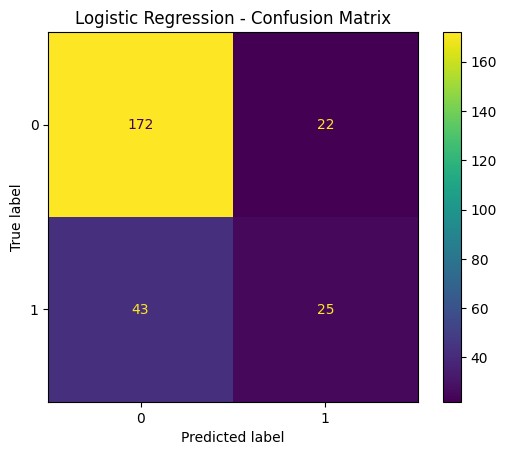

In [34]:
cm = confusion_matrix(y_test, logistic_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

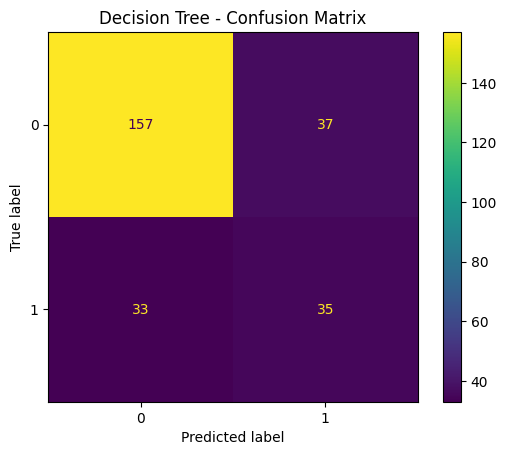

In [35]:
cm = confusion_matrix(y_test, decision_tree_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Decision Tree - Confusion Matrix")
plt.show()

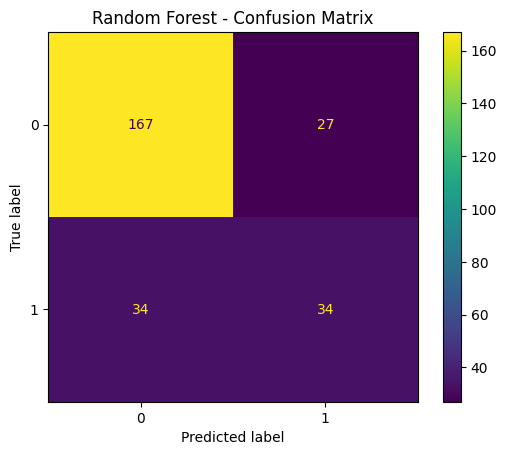

In [36]:
cm = confusion_matrix(y_test, random_forest_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [37]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Precision": [
        precision_score(y_test, logistic_pred),
        precision_score(y_test, decision_tree_pred),
        precision_score(y_test, random_forest_pred)
    ],
    "Recall": [
        recall_score(y_test, logistic_pred),
        recall_score(y_test, decision_tree_pred),
        recall_score(y_test, random_forest_pred)
    ],
    "F1-Score": [
        f1_score(y_test, logistic_pred),
        f1_score(y_test, decision_tree_pred),
        f1_score(y_test, random_forest_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, logistic_prob),
        roc_auc_score(y_test, decision_tree_prob),
        roc_auc_score(y_test, random_forest_prob)
    ]
})

results

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.531915,0.367647,0.434783,0.759475
1,Decision Tree,0.486111,0.514706,0.500000,0.693299
2,Random Forest,0.557377,0.500000,0.527132,0.790138


In [38]:
results.round(3)

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.532,0.368,0.435,0.759
1,Decision Tree,0.486,0.515,0.500,0.693
2,Random Forest,0.557,0.500,0.527,0.790


In [39]:
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test,
    logistic_prob
)

decision_tree_fpr, decision_tree_tpr, _ = roc_curve(
    y_test,
    decision_tree_prob
)

random_forest_fpr, random_forest_tpr, _ = roc_curve(
    y_test,
    random_forest_prob
)

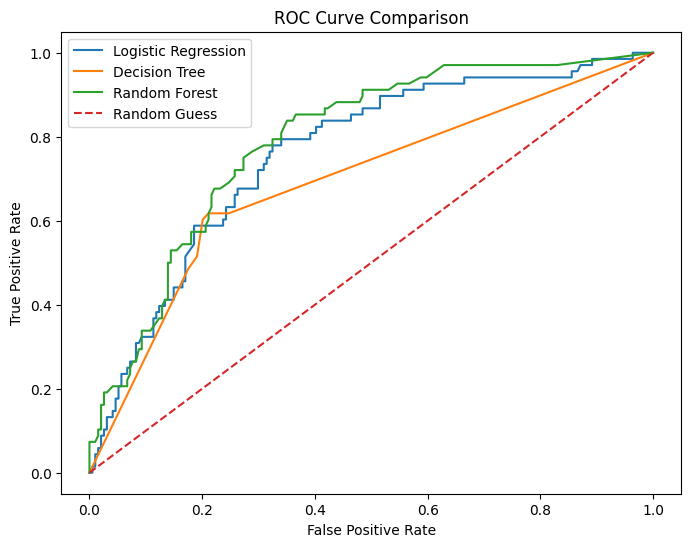

In [40]:
plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label="Logistic Regression"
)

plt.plot(
    decision_tree_fpr,
    decision_tree_tpr,
    label="Decision Tree"
)

plt.plot(
    random_forest_fpr,
    random_forest_tpr,
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Guess"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")

plt.legend()
plt.show()

In [41]:
best_model = results.loc[
    results["ROC-AUC"].idxmax()
]

best_model

,2
Model,Random Forest
Precision,0.557377
Recall,0.5
F1-Score,0.527132
ROC-AUC,0.790138


In [42]:
print(
    "Based on the ROC-AUC score,",
    best_model["Model"],
    "achieved the highest ROC-AUC score of",
    round(best_model["ROC-AUC"], 3)
)

Based on the ROC-AUC score, Random Forest achieved the highest ROC-AUC score of 0.79
